# Heat Equation on Polynomial Space

The heat operator $\partial_t - \partial_{xx}$ acts on the space of polynomials. Under the **heat flow**, the coefficients of a polynomial evolve, and the **roots** of the polynomial move in an interesting way.

## Heat equation for polynomials

If $p(x) = \sum_{k=0}^n a_k x^k$, then $\partial_{xx} p(x) = \sum_{k=2}^n k(k-1) a_k x^{k-2}$. The heat equation $\partial_t p = \partial_{xx} p$ on polynomial space is:
$$
\dot{a}_k(t) = (k+2)(k+1) a_{k+2}(t).
$$

## Root dynamics

Under heat flow, the roots $z_1(t), \ldots, z_n(t)$ of $p(\cdot, t)$ move according to (Lee and Lyons, 2014):
$$
\dot{z}_k = -\sum_{j \neq k} \frac{2}{z_k - z_j}.
$$
This is a **repulsive particle system**: roots repel each other! Starting from real roots, they can collide and become complex.

## Connection to Brownian motion

The heat equation on polynomials arises naturally when studying the zeros of random polynomials under Brownian motion of the coefficients. The dynamics are related to **Dyson Brownian motion** from random matrix theory.

## Degree preservation

The degree decreases over time: if $a_n \neq 0$, then $a_n$ is constant (the heat operator maps degree $n$ to degree $n-2$), but the top coefficient changes at rate $(n)(n-1) a_n$... wait, more precisely, the heat equation preserves the degree but drives high-frequency oscillations to zero.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ipywidgets import interact, IntSlider, FloatLogSlider

plt.rcParams['figure.dpi'] = 120

## Heat flow on polynomial coefficients

We track the coefficients of a polynomial under $\dot{a} = D^2 a$ where $D^2$ is the second-derivative operator on the coefficient vector.

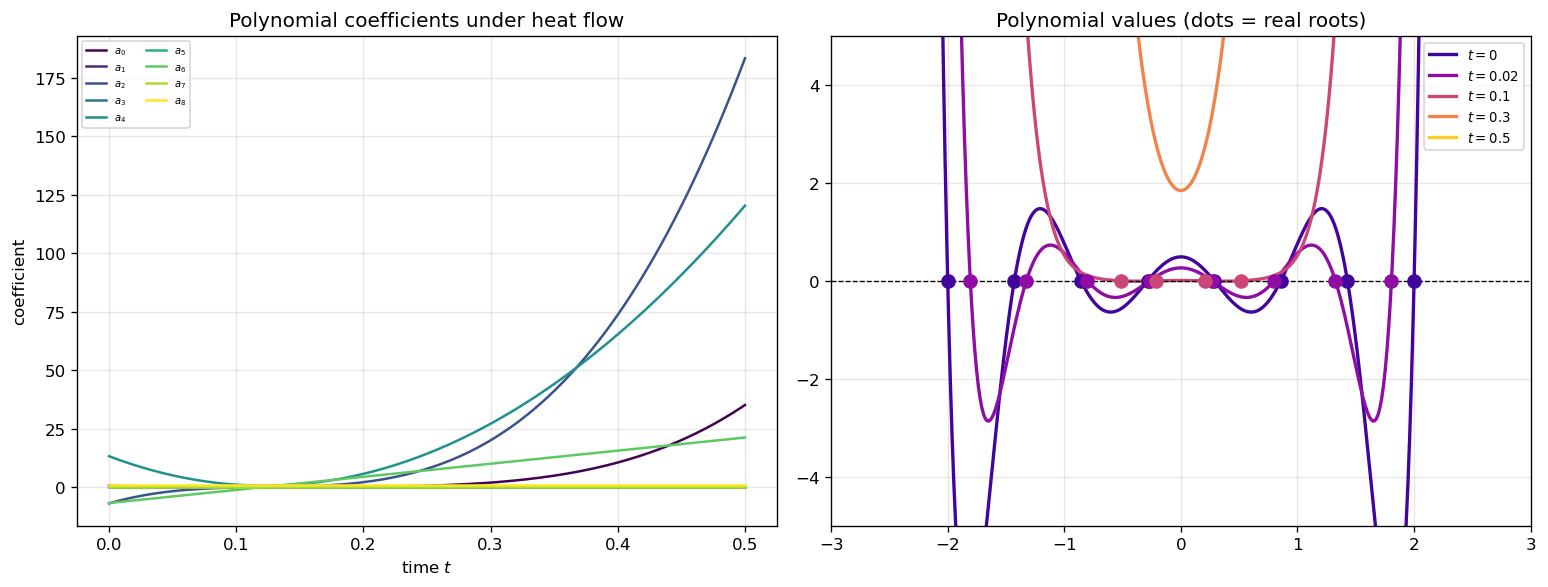

In [2]:
def second_deriv_matrix(n):
    """Matrix of d^2/dx^2 on polynomials of degree <= n-1.
    (sum a_k x^k)'' = sum k(k-1) a_k x^{k-2}
    """
    D2 = np.zeros((n, n))
    for k in range(2, n):
        D2[k-2, k] = k * (k-1)
    return D2

def poly_heat_flow(a0, T=1.0, n_steps=200):
    n = len(a0)
    D2 = second_deriv_matrix(n)
    t_eval = np.linspace(0, T, n_steps)
    sol = solve_ivp(lambda t, a: D2 @ a, (0, T), a0, t_eval=t_eval, dense_output=True)
    return sol.t, sol.y  # y: (n, n_steps)

# Initial polynomial: p(x) = prod(x - r_k), roots equally spaced on [-2, 2]
roots0 = np.linspace(-2, 2, 8)
a0 = np.poly(roots0)[::-1]  # coefficients ascending powers

t_ev, a_ev = poly_heat_flow(a0, T=0.5, n_steps=300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Coefficient evolution
cols = plt.cm.viridis(np.linspace(0, 1, len(a0)))
for k, col in enumerate(cols):
    axes[0].plot(t_ev, a_ev[k], color=col, lw=1.5, label=f'$a_{{{k}}}$')
axes[0].set_xlabel('time $t$'); axes[0].set_ylabel('coefficient')
axes[0].set_title('Polynomial coefficients under heat flow')
axes[0].legend(fontsize=6, ncol=2); axes[0].grid(alpha=0.3)

# Evaluate polynomial at several times
x_plot = np.linspace(-3, 3, 400)
t_show = [0, 0.02, 0.1, 0.3, 0.5]
cols2 = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_show)))
for t_s, col in zip(t_show, cols2):
    idx = np.argmin(np.abs(t_ev - t_s))
    a_t = a_ev[:, idx]
    p_t = np.polyval(a_t[::-1], x_plot)
    axes[1].plot(x_plot, p_t, color=col, lw=2, label=f'$t={t_s}$')
    roots_t = np.roots(a_t[::-1])
    real_roots = roots_t[np.abs(roots_t.imag) < 0.1].real
    axes[1].scatter(real_roots, np.zeros_like(real_roots), color=col, s=60, zorder=5)
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_xlim(-3, 3); axes[1].set_ylim(-5, 5)
axes[1].set_title('Polynomial values (dots = real roots)'); axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Root trajectories

We track the complex roots over time and observe the repulsion and possible complexification.

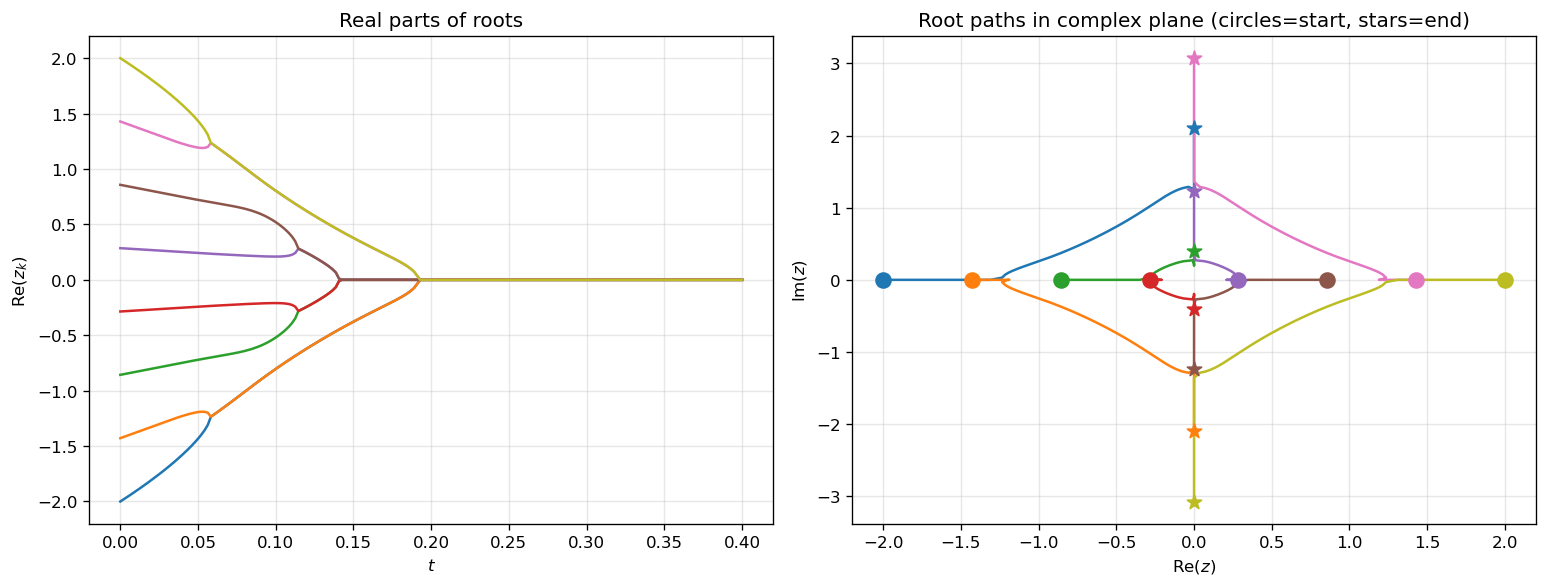

In [3]:
def get_root_trajectories(a0, T=0.5, n_steps=200):
    t_ev2, a_ev2 = poly_heat_flow(a0, T, n_steps)
    roots_traj = []
    for i in range(n_steps):
        r = np.roots(a_ev2[::-1, i])  # ascending -> descending
        roots_traj.append(r)
    return t_ev2, np.array(roots_traj)  # (n_steps, degree)

# Sort roots to track them consistently
def sort_roots(roots_traj):
    n_t, deg = roots_traj.shape
    sorted_r = np.zeros_like(roots_traj)
    sorted_r[0] = sorted(roots_traj[0], key=lambda z: z.real)
    for i in range(1, n_t):
        prev = sorted_r[i-1]
        curr = roots_traj[i]
        order = []
        remaining = list(range(deg))
        for p in prev:
            best = min(remaining, key=lambda j: abs(curr[j] - p))
            order.append(best); remaining.remove(best)
        sorted_r[i] = curr[order]
    return sorted_r

t_ev2, rt = get_root_trajectories(a0, T=0.4, n_steps=200)
rt_sorted = sort_roots(rt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cols_rt = plt.cm.tab10(np.linspace(0, 0.8, rt_sorted.shape[1]))

# Real part trajectories
for k, col in enumerate(cols_rt):
    axes[0].plot(t_ev2, rt_sorted[:,k].real, color=col, lw=1.5)
axes[0].set_xlabel('$t$'); axes[0].set_ylabel('$\\mathrm{Re}(z_k)$')
axes[0].set_title('Real parts of roots'); axes[0].grid(alpha=0.3)

# Complex plane trajectories
for k, col in enumerate(cols_rt):
    axes[1].plot(rt_sorted[:,k].real, rt_sorted[:,k].imag, color=col, lw=1.5)
    axes[1].scatter(rt_sorted[0,k].real, rt_sorted[0,k].imag, color=col, s=80, zorder=5)
    axes[1].scatter(rt_sorted[-1,k].real, rt_sorted[-1,k].imag, color=col, s=80, marker='*', zorder=5)
axes[1].set_xlabel('$\\mathrm{Re}(z)$'); axes[1].set_ylabel('$\\mathrm{Im}(z)$')
axes[1].set_title('Root paths in complex plane (circles=start, stars=end)')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Interactive: initial roots and total time

In [4]:
def show_poly_heat(n_roots=8, T=0.3):
    roots_i = np.linspace(-2, 2, n_roots)
    a_i = np.poly(roots_i)[::-1]
    t_i, a_ev_i = poly_heat_flow(a_i, T=T, n_steps=200)
    x_p = np.linspace(-3, 3, 300)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    cols_i = plt.cm.plasma(np.linspace(0, 0.8, 5))
    for frac, col in zip([0, 0.25, 0.5, 0.75, 1.0], cols_i):
        idx = int(frac * 199)
        p_t = np.polyval(a_ev_i[::-1, idx], x_p)
        t_val = t_i[idx]
        ax.plot(x_p, np.clip(p_t, -10, 10), color=col, lw=2, label=f'$t={t_val:.3f}$')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlim(-3, 3); ax.set_ylim(-8, 8)
    ax.set_title(f'Polynomial heat flow ($n={n_roots}$ roots, $T={T}$)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(show_poly_heat,
         n_roots=IntSlider(value=8, min=3, max=12, step=1, description='$n$ roots'),
         T=FloatLogSlider(value=-0.5, min=-2.0, max=0.0, step=0.25, description='$\\log_{10}T$'));

interactive(children=(IntSlider(value=8, description='$n$ roots', max=12, min=3), FloatLogSlider(value=0.01, d…

## Bibliographical resources

- Lee, Y.-T. and Lyons, C. (2014). Polynomial roots and the heat equation. *Preprint*.
- Dyson, F. J. (1962). A Brownian-motion model for the eigenvalues of a random matrix. *Journal of Mathematical Physics*, 3(6), 1191–1198.
- Borcea, J. and Brändén, P. (2009). The Lee–Yang and Pólya–Schur programs. *Communications of the American Mathematical Society*, 7, 1–71.
- Steinerberger, S. (2019). A heat flow regularity lemma for polynomial eigenvalue problems. *arXiv:1906.12041*.
- Walsh, J. L. (1922). On the location of the roots of the derivative of a polynomial. *Annals of Mathematics*, 24(1), 31–69.